# 16 — Synthetic Control for a Single Market Launch
**References:** Abadie & Gardeazabal (2003, *AER*) · Abadie, Diamond & Hainmueller (2010, *JASA*) · Abadie (2021, *J. Economic Literature*) · Arkhangelsky, Athey, Hirshberg, Imbens & Wager (2021, *AER*) "Synthetic Difference-in-Differences"

**Prerequisites:** causal_inference_course/10_synthetic_control.ipynb (full theory: donor
weight optimization, pre-treatment fit, permutation inference — not repeated here).
**Connects to:** causal_inference_course/10_synthetic_control.ipynb (identification theory this
notebook applies); 11_did_business.ipynb (a comparison design when many units are treated rather
than just one).

## Narrative thread
```
Business question: did opening a new flagship store in one city lift regional sales?
   -> Only one treated unit -> classical DiD/regression comparisons don't have a natural control
   -> Build a synthetic control from a donor pool of untreated markets
   -> Check pre-treatment fit -> read off the post-treatment gap
   -> Placebo-in-space inference across every donor
   -> Applied-level extensions: generalized synthetic control, synthetic DiD
```

## Why this notebook exists

Synthetic control was built for exactly this situation: **one** treated unit (a single region,
store, or market) and a handful of plausible comparison units, none of which is obviously the
"right" single control. `causal_inference_course/10` derives the donor-weight optimization
problem and its inference theory; this notebook runs the full applied workflow on a concrete
business case — a company opening its first flagship store in a new metro market — and focuses
on the two things a practitioner actually needs to get right: **donor pool selection** and
**placebo-in-space inference**, since with $n=1$ treated unit there is no other way to get a
sense of statistical significance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(16)

## Business setting: a flagship store opening

A retailer opens its first flagship store in Market A in month 24 of a 48-month window. We
have monthly regional sales for Market A and 19 other markets that never got a flagship store
(the donor pool). Markets share a common macro trend (industry-wide seasonality/growth) but
differ in their baseline level and sensitivity to that trend — exactly the setting where a
weighted combination of donors can track Market A's pre-period path better than any single
comparison market.

In [2]:
# ── Simulate 20 markets (1 treated, 19 donors) sharing a common trend factor ──
n_markets = 20
n_months = 48
treat_month = 24
market_names = ["A"] + [f"D{i}" for i in range(1, n_markets)]

common_trend = np.cumsum(np.random.normal(0.6, 1.0, n_months))          # shared macro factor
market_level = np.random.uniform(80, 160, n_markets)                    # baseline sales level per market
market_loading = np.random.uniform(0.5, 1.5, n_markets)                 # sensitivity to the common trend

true_lift = 18.0  # true causal lift in monthly sales from the flagship store, post-opening

sales = np.zeros((n_markets, n_months))
for m in range(n_markets):
    sales[m] = market_level[m] + market_loading[m] * common_trend + np.random.normal(0, 2.5, n_months)
sales[0, treat_month:] += true_lift  # market A (index 0) gets the treatment effect post-opening

panel = pd.DataFrame(sales.T, columns=market_names)
panel["month"] = np.arange(n_months)
panel.head()

,A,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,month
0,160.355137,143.697597,114.737096,156.316423,88.021780,138.090401,136.596211,123.028118,129.210156,135.454992,...,149.784917,91.077734,99.368563,138.846846,110.089671,107.079052,92.006260,87.775853,112.172921,0
1,157.284324,143.721432,113.355657,155.787926,84.754752,133.973304,137.585025,119.891052,120.725182,135.244297,...,139.304786,86.274283,97.775318,139.590753,110.201159,108.527775,92.658278,82.690777,109.272851,1
2,154.973577,150.199169,112.811398,152.099216,78.015461,136.963120,131.149991,121.786713,127.016817,138.898005,...,145.744991,89.332495,98.267086,136.848626,110.914049,107.934890,93.034168,82.012518,111.470958,2
3,160.557866,149.085127,112.751660,158.998736,85.452616,138.525134,133.742200,122.918855,126.964441,139.698971,...,144.126412,86.671109,95.589746,136.054354,104.949807,104.766828,90.349632,83.806894,114.859018,3
4,158.859050,145.150895,117.812005,154.703142,84.169860,137.766606,136.413686,119.714888,126.459546,135.672878,...,145.483300,92.772775,93.483405,136.113045,115.053306,109.385864,90.172463,87.382425,109.269801,4


## Building the synthetic control

Following Abadie et al., choose non-negative donor weights $w_j \ge 0$, $\sum_j w_j = 1$ that
minimize the pre-treatment gap between Market A and the weighted donor average:

$$\min_{w} \sum_{t < T_0} \left(Y_{A,t} - \sum_{j \in \text{donors}} w_j Y_{j,t}\right)^2
\quad \text{s.t. } w_j \ge 0, \sum_j w_j = 1$$

We solve this with constrained numerical optimization (the theory behind *why* this specific
convex-combination restriction is the right one — versus, say, allowing negative weights or
extrapolating — is covered in `causal_inference_course/10`; here we implement it directly).

In [3]:
donors = market_names[1:]
pre = panel.loc[panel.month < treat_month, donors].values   # pre-period donor sales, T0 x J
target_pre = panel.loc[panel.month < treat_month, "A"].values

def loss(w):
    return np.sum((target_pre - pre @ w) ** 2)

n_donors = len(donors)
w0 = np.full(n_donors, 1 / n_donors)
constraints = ({"type": "eq", "fun": lambda w: w.sum() - 1},)
bounds = [(0, 1)] * n_donors

result = minimize(loss, w0, method="SLSQP", bounds=bounds, constraints=constraints)
weights = pd.Series(result.x, index=donors).sort_values(ascending=False)
print("Top donor weights:")
print(weights[weights > 0.01].round(3))
print(f"\nPre-treatment RMSE (synthetic vs. actual Market A): {np.sqrt(loss(result.x) / treat_month):.3f}")

Top donor weights:
D3    1.0
dtype: float64

Pre-treatment RMSE (synthetic vs. actual Market A): 2.906


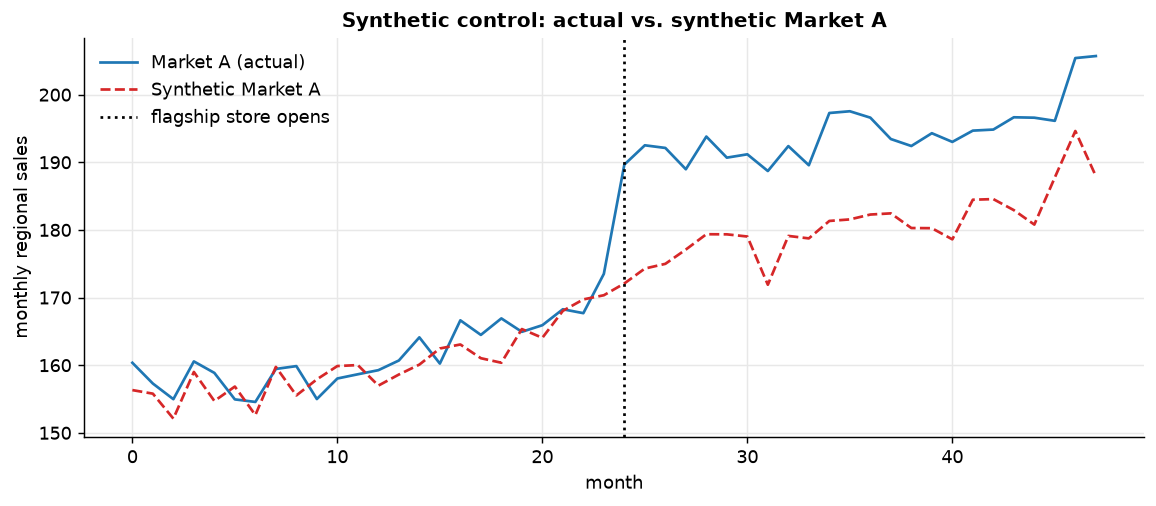

Average post-opening gap (estimated treatment effect): 13.68  (true = 18.0)


In [4]:
# ── Construct the full synthetic control series and plot vs. actual Market A ──
synthetic = panel[donors].values @ result.x
panel["synthetic_A"] = synthetic

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(panel["month"], panel["A"], color="#1f77b4", label="Market A (actual)")
ax.plot(panel["month"], panel["synthetic_A"], color="#d62728", ls="--", label="Synthetic Market A")
ax.axvline(treat_month, color="black", ls=":", label="flagship store opens")
ax.set_xlabel("month"); ax.set_ylabel("monthly regional sales")
ax.set_title("Synthetic control: actual vs. synthetic Market A")
ax.legend(); plt.tight_layout(); plt.show()

post_gap = (panel.loc[panel.month >= treat_month, "A"] - panel.loc[panel.month >= treat_month, "synthetic_A"]).mean()
print(f"Average post-opening gap (estimated treatment effect): {post_gap:.2f}  (true = {true_lift})")

## Donor pool selection guidance

The optimization above will assign near-zero weight to donors that don't help replicate
Market A's pre-trend, but **which markets are even eligible to be donors matters before you
run the optimizer**:

1. **Exclude markets that were also treated** (e.g., other cities that got a flagship store,
   even a *different* one, in the same window) — a "control" that received a similar
   intervention contaminates the counterfactual.
2. **Exclude markets structurally different in ways not captured by the outcome history**
   (e.g., a market undergoing an unrelated regulatory change, a natural disaster, or a
   completely different customer base) — pre-trend fit alone won't catch a *future* shock
   that's uncorrelated with the past.
3. **Prefer a moderately sized, economically similar donor pool** — too few donors leaves no
   flexibility to match the pre-trend; too many (especially with a short pre-period) invites
   overfitting to noise, since the optimizer has more freedom to chase pre-period quirks that
   don't reflect real structural similarity (Abadie 2021 recommends keeping the donor pool
   restricted to comparable units rather than "everything available").
4. **A long, stable pre-treatment window** protects against exactly that overfitting risk —
   good pre-treatment fit over a longer window is much more convincing than a perfect fit over
   a handful of pre-periods.

## Placebo-in-space inference

With a single treated unit there's no classical standard error. Abadie et al. (2010)'s fix:
**apply the identical synthetic-control procedure to every donor**, pretending each was the
treated unit in turn, and compare Market A's post/pre fit ratio to the placebo distribution. If
Market A's gap is unusually large relative to the placebo runs (most of which have no true
effect by construction), that's evidence of a real effect.

In [5]:
def fit_synthetic_and_gap(panel, treated_col, donor_cols, treat_month):
    pre_treated = panel.loc[panel.month < treat_month, treated_col].values
    pre_donors = panel.loc[panel.month < treat_month, donor_cols].values

    def loss_fn(w):
        return np.sum((pre_treated - pre_donors @ w) ** 2)

    n = len(donor_cols)
    res = minimize(loss_fn, np.full(n, 1 / n), method="SLSQP",
                    bounds=[(0, 1)] * n, constraints=({"type": "eq", "fun": lambda w: w.sum() - 1},))
    synth = panel[donor_cols].values @ res.x
    pre_rmse = np.sqrt(loss_fn(res.x) / treat_month)
    post_actual = panel.loc[panel.month >= treat_month, treated_col].values
    post_synth = synth[treat_month:]
    post_rmse = np.sqrt(np.mean((post_actual - post_synth) ** 2))
    return pre_rmse, post_rmse, (post_rmse / pre_rmse if pre_rmse > 1e-6 else np.inf)

# run the same procedure with each donor as the "placebo treated" unit (all other markets as its donor pool)
placebo_ratios = {}
all_units = market_names
for placebo_unit in donors:  # exclude the true treated unit "A"
    placebo_donors = [u for u in all_units if u != placebo_unit]
    pre_r, post_r, ratio = fit_synthetic_and_gap(panel, placebo_unit, placebo_donors, treat_month)
    placebo_ratios[placebo_unit] = ratio

pre_r_A, post_r_A, ratio_A = fit_synthetic_and_gap(panel, "A", donors, treat_month)
placebo_ratios["A (actual treated)"] = ratio_A

ratios = pd.Series(placebo_ratios).sort_values(ascending=False)
rank_of_A = (ratios.index.get_loc("A (actual treated)") + 1)
p_like = rank_of_A / len(ratios)
print(ratios.round(2))
print(f"\nMarket A's post/pre RMSE ratio ranks {rank_of_A} of {len(ratios)} (1 = most extreme).")
print(f"Placebo-based 'p-value' (rank / n): {p_like:.3f}")

D10                   4.83
A (actual treated)    4.80
D3                    4.78
D6                    4.56
D5                    2.86
D16                   2.41
D1                    2.13
D15                   2.05
D8                    1.89
D19                   1.44
D7                    1.39
D9                    1.33
D13                   1.32
D17                   1.17
D4                    1.08
D14                   1.06
D2                    1.04
D12                   0.87
D18                   0.86
D11                   0.67
dtype: float64

Market A's post/pre RMSE ratio ranks 2 of 20 (1 = most extreme).
Placebo-based 'p-value' (rank / n): 0.100


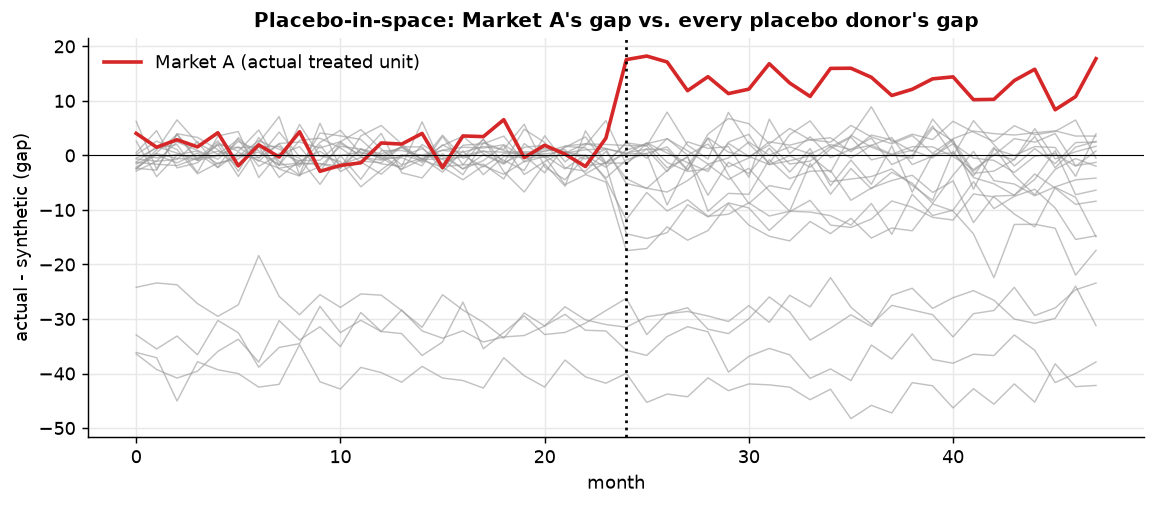

In [6]:
# ── Visualize: gap paths for every placebo unit vs. Market A ──
fig, ax = plt.subplots(figsize=(9, 4))
for placebo_unit in donors:
    placebo_donors = [u for u in all_units if u != placebo_unit]
    pre_treated = panel.loc[panel.month < treat_month, placebo_unit].values
    pre_d = panel.loc[panel.month < treat_month, placebo_donors].values
    n = len(placebo_donors)
    res = minimize(lambda w: np.sum((pre_treated - pre_d @ w) ** 2), np.full(n, 1 / n),
                    method="SLSQP", bounds=[(0, 1)] * n,
                    constraints=({"type": "eq", "fun": lambda w: w.sum() - 1},))
    synth = panel[placebo_donors].values @ res.x
    gap = panel[placebo_unit].values - synth
    ax.plot(panel["month"], gap, color="#999999", lw=0.8, alpha=0.6)

gap_A = panel["A"].values - panel["synthetic_A"].values
ax.plot(panel["month"], gap_A, color="#d62728", lw=2, label="Market A (actual treated unit)")
ax.axvline(treat_month, color="black", ls=":")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("month"); ax.set_ylabel("actual - synthetic (gap)")
ax.set_title("Placebo-in-space: Market A's gap vs. every placebo donor's gap")
ax.legend(); plt.tight_layout(); plt.show()

## Applied-level extensions

- **Generalized synthetic control** (Xu 2017) extends the method to *multiple* treated units
  and estimates a latent factor model, blending synthetic control with the fixed-effects
  panel ideas from `14_fixed_effects_panel.ipynb` — useful when several markets get the
  flagship treatment at different times (a hybrid of this notebook and `11_did_business.ipynb`).
- **Synthetic Difference-in-Differences** (Arkhangelsky, Athey, Hirshberg, Imbens & Wager 2021,
  *AER*) combines synthetic control's donor-weighting with DiD's unit- and time-fixed-effects
  structure, adding time weights as well as unit weights. It tends to be more robust than plain
  synthetic control when the pre-treatment fit isn't perfect, and comes with a built-in
  placebo-based inference procedure. In practice, reach for `synthdid`-style packages when the
  application has multiple treated units or an imperfect pre-period fit — plain synthetic
  control (as implemented here) is best suited to the classic single-treated-unit case with
  good pre-trend fit.

## Practitioner checklist

1. **Justify the donor pool before optimizing weights** — exclude co-treated and structurally
   dissimilar markets.
2. **Report pre-treatment fit explicitly** (RMSE, or a plot) — a synthetic control that cannot
   track the pre-period has no business being trusted in the post-period.
3. **Always run placebo-in-space inference** — with one treated unit, this is the only
   credible substitute for a standard error.
4. **Watch for a short pre-period** — it inflates the risk of an overfit synthetic control
   that looks great pre-treatment by chance and says nothing about the post-treatment
   counterfactual.
5. **Consider generalized synthetic control / synthetic DiD** as soon as there is more than one
   treated unit, or the pre-treatment fit is imperfect.

## Key takeaways

| Concept | Statement |
|---|---|
| Synthetic control | A convex combination of donor units built to match the treated unit's pre-trend |
| Donor pool | The single biggest judgment call; must exclude co-treated/dissimilar units |
| Pre-treatment fit | Non-negotiable prerequisite for trusting the post-treatment gap |
| Placebo-in-space | Apply the same procedure to every donor to build an inference distribution |
| Extensions | Generalized synthetic control / synthetic DiD handle multiple treated units, imperfect fit |

## References

| Author(s) | Title | Role here |
|---|---|---|
| Abadie & Gardeazabal (2003, *AER*) | "The Economic Costs of Conflict" | Original synthetic control application |
| Abadie, Diamond & Hainmueller (2010, *JASA*) | "Synthetic Control Methods for Comparative Case Studies" | Donor weighting, placebo inference |
| Abadie (2021, *J. Economic Literature*) | "Using Synthetic Controls" | Practical guardrails, donor pool guidance |
| Arkhangelsky, Athey, Hirshberg, Imbens & Wager (2021, *AER*) | "Synthetic Difference-in-Differences" | Applied-level extension |
